<a href="https://colab.research.google.com/github/henriqueprrpnunes/MVP_ML_-_Analytics/blob/main/MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Henrique Nunes_  
**Dataset:** _[Housing](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download)_  
**Tipo de problema:** _Regressão_  


## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☒ |
| Dataset descrito, com fonte, atributos e restrições | ☒ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☒ |
| Análise exploratória objetiva, conectada à modelagem | ☒ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☒ |
| Prevenção de vazamento de dados | ☒ |
| Tratamentos de dados justificados | ☒ |
| Pipeline ou sequência reprodutível de pré-processamento | ☒ |
| Modelo baseline definido | ☒ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☒ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☒ |
| Avaliação com métricas coerentes com o problema | ☒ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☒ |
| Código limpo, organizado e executável do início ao fim | ☒ |
| Conclusão conectada ao objetivo inicial | ☒ |

# 1. Definição do problema

## 1.1 Descrição do problema

O mercado imobiliário é um setor de grande relevância econômica, no qual a definição adequada do preço de um imóvel é fundamental para compradores, vendedores, investidores e empresas do ramo. Entretanto, o valor de uma residência é influenciado por diversos fatores, como área construída, número de quartos e banheiros, vagas de estacionamento, localização, presença de comodidades e nível de mobília, tornando a precificação uma tarefa complexa e sujeita a subjetividades.

Nesse contexto, este projeto busca investigar a relação entre as características dos imóveis e seus respectivos preços, utilizando técnicas de análise de dados e ciência de dados. O objetivo é compreender quais atributos exercem maior influência sobre o valor de mercado das residências e desenvolver uma base analítica que possa apoiar a previsão de preços de imóveis.

A solução proposta pode ser utilizada por imobiliárias, corretores, investidores e proprietários que desejam obter estimativas mais consistentes do valor de mercado de uma residência, auxiliando processos de compra, venda e avaliação patrimonial.

A relevância do problema está no fato de que decisões relacionadas ao mercado imobiliário envolvem valores financeiros elevados e podem gerar impactos significativos para os envolvidos. Além disso, a utilização de métodos baseados em dados contribui para reduzir a subjetividade nas avaliações e fornecer informações mais confiáveis para a tomada de decisão.



## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o preço de imóveis residenciais a partir de suas características físicas e de localização. Para isso, serão comparados diferentes algoritmos de regressão, incluindo um modelo baseline e modelos baseados em árvores de decisão, buscando identificar a abordagem com melhor desempenho preditivo e compreender os fatores que mais influenciam o valor dos imóveis.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão  

**Justificativa:** Este projeto caracteriza-se como um problema de regressão, pois o objetivo é prever o valor de uma variável numérica contínua: o preço do imóvel. Neste caso o modelo deve estimar um valor monetário a partir de características do imóvel, como área, número de quartos, banheiros, vagas de estacionamento, localização e presença de comodidades.

Além disso, o conjunto de dados possui exemplos rotulados, ou seja, para cada imóvel são conhecidas tanto suas características quanto seu respectivo preço. Dessa forma, trata-se de um problema de aprendizado supervisionado, no qual o modelo aprende padrões existentes nos dados históricos para realizar previsões sobre novos imóveis.



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. A área do imóvel é uma das variáveis mais relevantes para explicar o preço.
Espera-se que imóveis com maior área apresentem preços mais elevados.
2. Características de conforto e infraestrutura influenciam positivamente o preço dos imóveis.
Imóveis com ar-condicionado, aquecimento de água, garagem e quarto de hóspedes tendem a possuir maior valor de mercado.
3. Modelos capazes de capturar relações não lineares apresentarão melhor desempenho do que uma regressão linear simples.
Espera-se que algoritmos como Random Forest consigam identificar padrões mais complexos presentes nos dados e produzam previsões mais precisas.

**Critérios de sucesso:**
- Métrica principal: RMSE (Root Mean Squared Error) e R² (Coeficiente de Determinação).
- Resultado mínimo esperado: obter desempenho superior ao modelo baseline, reduzindo o RMSE e aumentando o valor de R² no conjunto de teste.
- Restrição prática: o modelo deve apresentar tempo de treinamento compatível com a dimensão da base de dados e produzir resultados suficientemente interpretáveis para permitir a identificação das características mais relevantes na precificação dos imóveis.



# 2. Ambiente, bibliotecas e reprodutibilidade


In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [ ]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset [Housing](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download) é um conjunto de dados amplamente disponibilizado no Kaggle. Tem uma nota de usabilidade perfeita, sendo uma base completa, compatível e com ótima credibilidade.


## 3.2 Carga dos dados


In [ ]:
# caminho do arquivo
path = "https://raw.githubusercontent.com/henriqueprrpnunes/MVP_Analise_de_Dados_e_Boas_Praticas/main/Housing"

# guardar dataset em um dataframe
df = pd.read_csv(path, sep=';')

# primeiras linhas
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3.3 Visão geral do dataset



In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (545, 13)

Tipos de dados:


,tipo
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,4060000,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6650000,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,3710000,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,6440000,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,2800000,3960,3,1,1,yes,no,no,no,no,0,no,furnished


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| area | Numérica | Área do imóvel | sim | motivo |
| bedrooms | Numérica | Número de quartos do imóvel | sim | motivo |
| bathrooms | Numérica | Número de quartos do imóvel | sim | motivo |
| stories | Numérica | Número de andares da residência | sim | motivo |
| mainroad | Categórica binária | Indica se o imóvel possui acesso à via principal | sim | motivo |
| guestroom | Categórica binária | Indica a presença de quarto de hóspedes | sim | motivo |
| basement | Categórica binária | Indica a presença de porão | sim | motivo |
| hotwaterheating | Categórica binária | Indica a existência de sistema de aquecimento de água | sim | motivo |
| airconditioning | Categórica binária | Indica a presença de ar-condicionado | sim | motivo |
| parking | Numérica | Quantidade de vagas de estacionamento disponíveis | sim | motivo |
| prefarea | Categórica binária | Indica se o imóvel está localizado em uma área considerada preferencial ou valorizada | sim | motivo |
| furnishingstatus | Categórica nominal | Nível de mobília do imóvel | sim | motivo |
| price | Numérica | Preço do imóvel | sim | valor previsto (alvo) |


# 4. Análise exploratória dos dados

Nesta etapa busca-se entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.


## Variáveis numéricas

A análise das variáveis numéricas constitui a etapa inicial da exploração dos dados, com o objetivo de compreender a estrutura, distribuição e comportamento dos principais atributos quantitativos do conjunto de dados.

### Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


A tabela de estatísticas descritivas acima já traz vários insights importantes sobre o comportamento dos preços dos imóveis e de algumas variáveis explicativas.

A variável alvo, preço (price), apresenta média de aproximadamente 4,77 milhões e mediana de 4,34 milhões, indicando assimetria à direita. Isso sugere a presença de imóveis de alto valor que elevam a média. O desvio padrão elevado (1,87 milhões) e a diferença significativa entre o terceiro quartil (5,74 milhões) e o valor máximo (13,3 milhões) reforçam a existência de outliers. Esse comportamento indica a necessidade de considerar transformações, como logaritmo, para estabilizar a variância e melhorar o desempenho de modelos preditivos.

A variável área (area) também apresenta assimetria à direita, com média de 5.150 e mediana de 4.600. O valor máximo (16.200) é muito superior ao terceiro quartil (6.360), evidenciando a presença de outliers. Além disso, o alto desvio padrão indica grande variabilidade no tamanho dos imóveis. Essa variável tende a ter forte relação com o preço e também é candidata à transformação logarítmica.

As variáveis estruturais do imóvel apresentam menor dispersão. O número de quartos (bedrooms) possui média próxima de 3 e baixa variabilidade, indicando concentração em imóveis de padrão intermediário. O número de banheiros (bathrooms) apresenta média de 1,29 e mediana igual a 1, sugerindo predominância de imóveis com apenas um banheiro e leve assimetria à direita. A variável número de andares (stories) possui média de 1,8 e mediana de 2, indicando predominância de imóveis térreos ou com dois pavimentos.

A variável vagas de estacionamento (parking) apresenta média de 0,69 e mediana igual a 0, indicando que a maioria dos imóveis não possui vaga. A distribuição é assimétrica, com poucos imóveis possuindo múltiplas vagas.

De forma geral, observa-se que as variáveis preço e área possuem alta variabilidade e presença de outliers, enquanto as demais variáveis apresentam distribuições mais concentradas. Além disso, há diferenças significativas de escala entre as variáveis, o que pode impactar determinados modelos de machine learning.

Esses resultados indicam a necessidade de tratamento de assimetria, possível transformação de variáveis e análise adicional de correlação, especialmente entre área e preço.

### Histograma e Gráfico de Barras

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). Para variáveis contínuas, principalmente, o histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais. Enquanto isso, os gráficos de barras são mais eficientes para as variáveis discretas.

#### *Preço (price)*

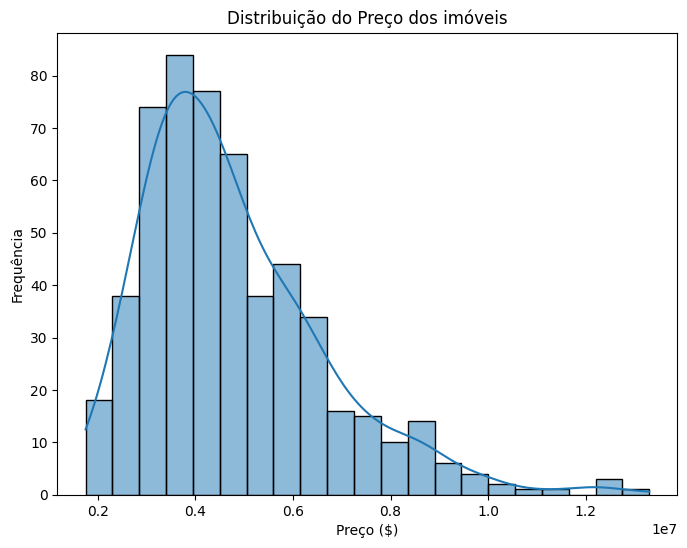

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do preço
sns.histplot(df['price'], kde=True)
plt.title('Distribuição do Preço dos imóveis')
plt.xlabel('Preço ($)')
plt.ylabel('Frequência')
plt.show()

O histograma da variável price evidencia uma distribuição assimétrica à direita. A maior concentração de imóveis está na faixa entre aproximadamente 3 e 6 milhões, com pico em torno de 3,5 a 4,5 milhões, indicando que esse é o padrão predominante do mercado na base analisada.

Observa-se uma cauda longa à direita, com poucos imóveis atingindo valores significativamente mais altos, chegando a mais de 12 milhões. Isso confirma a presença de outliers, que elevam a média e aumentam a variabilidade da variável.

A distribuição não segue um formato normal, sendo claramente enviesada. Esse comportamento sugere a necessidade de transformação, como o uso de logaritmo na variável price, para reduzir a assimetria, estabilizar a variância e melhorar o desempenho de modelos preditivos, especialmente os baseados em regressão.

#### *Área (area)*

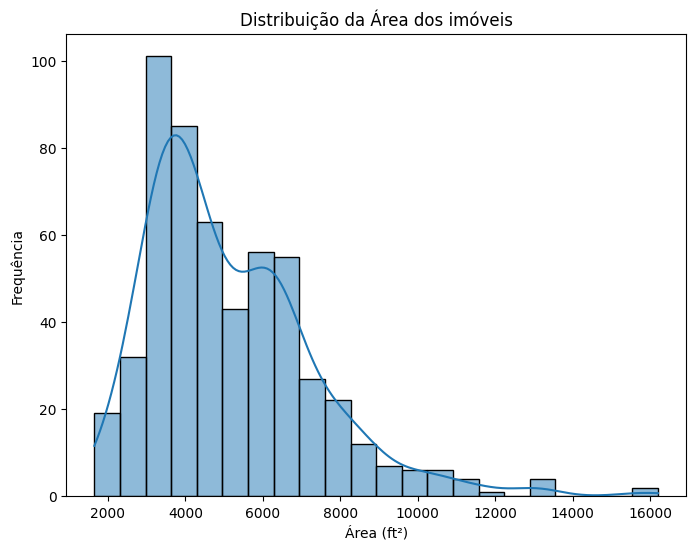

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma da área
sns.histplot(df['area'], kde=True)
plt.title('Distribuição da Área dos imóveis')
plt.xlabel('Área (ft²)')
plt.ylabel('Frequência')
plt.show()

O histograma da variável area mostra uma distribuição assimétrica à direita, com maior concentração de imóveis entre aproximadamente 3.000 e 6.000 ft². O pico da distribuição ocorre nessa faixa, indicando que esse é o padrão mais comum de tamanho dos imóveis na base.

Observa-se uma cauda longa à direita, com poucos imóveis apresentando áreas muito superiores, chegando a valores acima de 15.000 ft². Isso evidencia a presença de outliers e alta variabilidade na variável.

A distribuição não é normal e apresenta enviesamento, comportamento semelhante ao observado na variável price. Esse padrão reforça a relação esperada entre área e preço e indica que a variável area também pode se beneficiar de transformação logarítmica, visando reduzir a assimetria e melhorar a estabilidade dos modelos preditivos.

#### *Quartos (bedrooms)*

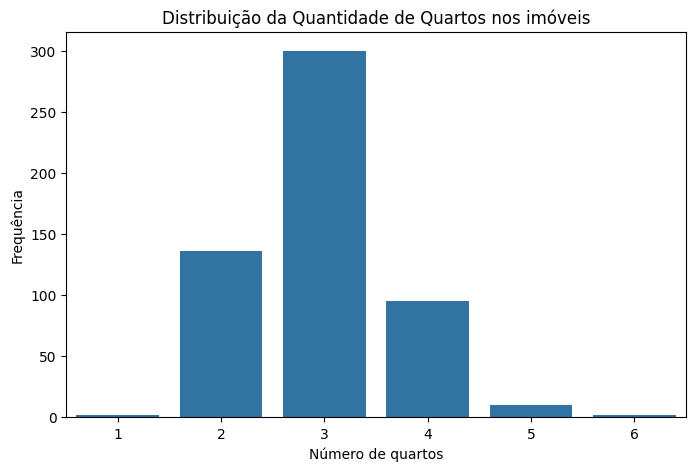

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico barras de quartos
sns.countplot(x='bedrooms', data=df, order=sorted(df['bedrooms'].unique()))
plt.title('Distribuição da Quantidade de Quartos nos imóveis')
plt.xlabel('Número de quartos')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável bedrooms evidencia forte concentração em imóveis com apenas 3 quartos, que representam a grande maioria da base. Do ponto de vista de dispersão, os dados apresentam uma forte concentração central, com a grande maioria da amostra situada no intervalo de 2 a 4 quartos.

As categorias 1, 5 e 6 quartos apresentam frequências marginais, caracterizando-se como classes sub-representadas de frequência na base de dados.

#### *Banheiros (bathrooms)*

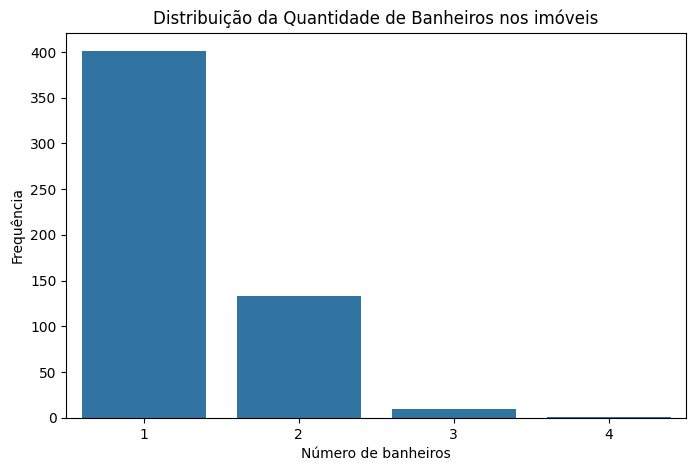

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico barras de banheiros
sns.countplot(x='bathrooms', data=df, order=sorted(df['bathrooms'].unique()))
plt.title('Distribuição da Quantidade de Banheiros nos imóveis')
plt.xlabel('Número de banheiros')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável bathrooms evidencia forte concentração em imóveis com apenas 1 banheiro, que representam a grande maioria da base. Em seguida, observa-se uma quantidade menor de imóveis com 2 banheiros, enquanto valores de 3 ou mais banheiros são raros.

Essa distribuição indica baixa variabilidade e uma assimetria à direita, com poucos imóveis de padrão mais elevado no que se refere à quantidade de banheiros. Esse comportamento sugere que a variável pode ter poder discriminatório principalmente na diferenciação entre imóveis básicos (1 banheiro) e intermediários (2 banheiros), mas com menor capacidade de capturar variações em imóveis de alto padrão devido à baixa frequência nesses níveis.

#### *Andares (stories)*

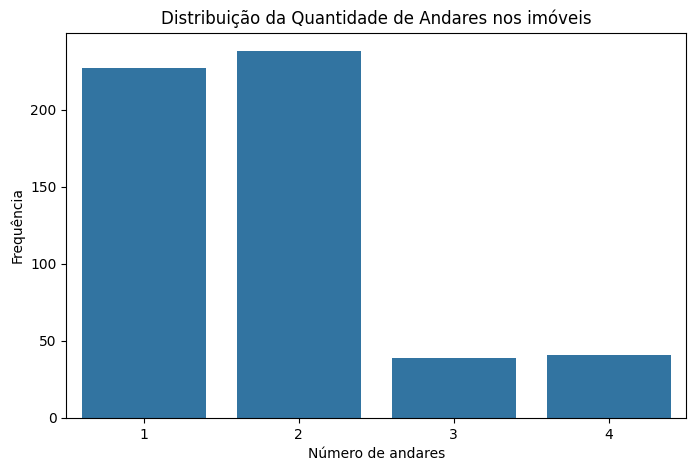

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico barras de andares
sns.countplot(x='stories', data=df, order=sorted(df['stories'].unique()))
plt.title('Distribuição da Quantidade de Andares nos imóveis')
plt.xlabel('Número de andares')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável stories revela uma distribuição com concentração predominante nos níveis inferiores, com a moda situada em 2 andares.

Observa-se uma forte representatividade de imóveis com 1 e 2 andares, que juntos compõem a vasta maioria da amostra, enquanto as categorias de 3 e 4 andares apresentam uma queda drástica na frequência.

#### *Estacionamentos (parking)*

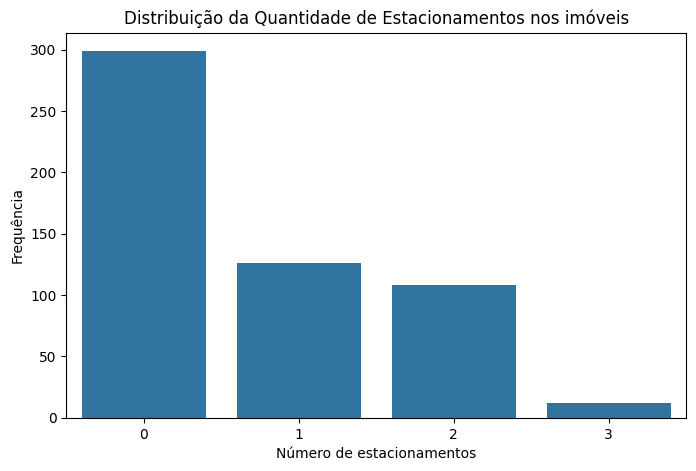

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico barras de estacionamentos
sns.countplot(x='parking', data=df, order=sorted(df['parking'].unique()))
plt.title('Distribuição da Quantidade de Estacionamentos nos imóveis')
plt.xlabel('Número de estacionamentos')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da váriavel parking apresenta uma concentração predominante de imóveis sem estacionamento, seguida por uma redução significativa na frequência para as categorias de 1 vaga e 2 vagas.

A categoria de 3 vagas apresenta-se como uma classe sub-representada, com uma frequência significativamente menor dentre todas as outras.

### Boxplot

Os gráficos de Boxplot para as variáveis contínuas do conjunto de dados tem como objetivo de avaliar a dispersão, a posição central e a presença de valores extremos (outliers). Essa abordagem permite uma visualização mais objetiva da variabilidade dos dados e da existência de observações atípicas. A identificação desses pontos é importante para orientar decisões de tratamento, como transformações ou remoção de outliers.

#### *Preço (price)*

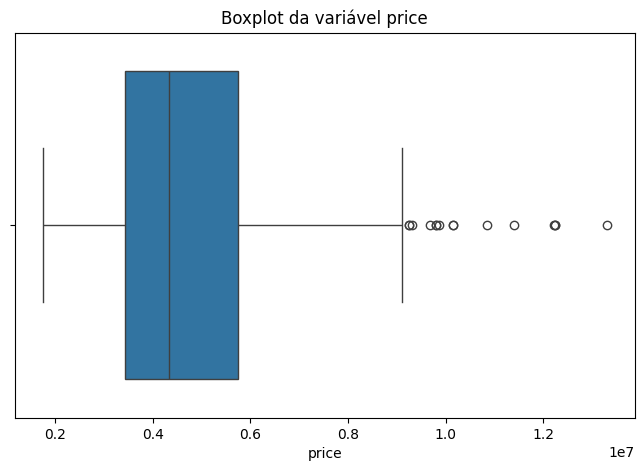

In [ ]:
#Boxplot Preço

plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title('Boxplot da variável price')
plt.xlabel('price')

plt.show()

In [ ]:
# Cálculo dos quartis
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Selecionando apenas os valores outliers
outliers = df.loc[
    (df['price'] < limite_inferior) | (df['price'] > limite_superior),
    'price'
]

# Exibindo valores de outliers
print(outliers.values)

[13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000  9800000  9681000  9310000  9240000  9240000]


#### *Área (area)*

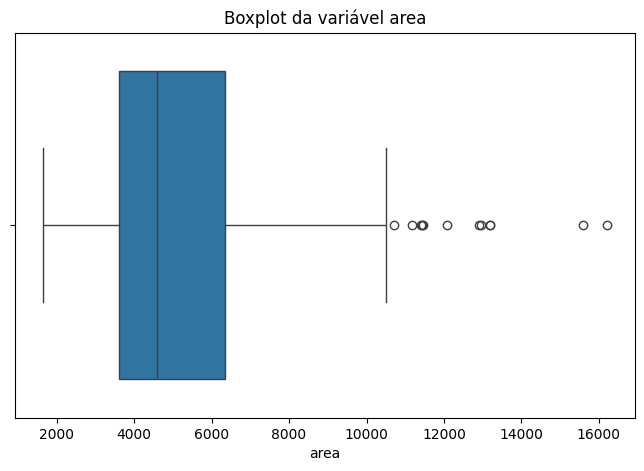

In [ ]:
#Boxplot Área

plt.figure(figsize=(8,5))

sns.boxplot(x=df['area'])

plt.title('Boxplot da variável area')
plt.xlabel('area')

plt.show()

In [ ]:
# Cálculo dos quartis
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Selecionando apenas os valores outliers
outliers = df.loc[
    (df['area'] < limite_inferior) | (df['area'] > limite_superior),
    'area'
]

# Exibindo valores de outliers
print(outliers.values)

[16200 13200 11440 11175 13200 12090 15600 11460 11410 10700 12900 12944]


A análise dos outliers identificados para as variáveis price e area confirma a presença de imóveis de padrão significativamente superior ao restante da base, o que já havia sido sugerido pelas estatísticas descritivas e histogramas.

No caso de price, os valores outliers variam aproximadamente entre 9,24 milhões e 13,3 milhões, situando-se muito acima da faixa onde se concentra a maior parte dos dados. A repetição de alguns valores indica que não se tratam de erros pontuais, mas sim de um subconjunto consistente de imóveis de alto padrão. Esses imóveis exercem forte influência sobre a média e aumentam a variabilidade da variável, podendo impactar modelos sensíveis a extremos, como regressões lineares.

Para a variável area, os outliers variam entre aproximadamente 10.700 e 16.200, também muito acima do padrão central da distribuição. Assim como no preço, esses valores indicam a existência de imóveis significativamente maiores, o que reforça a relação estrutural entre área e preço. A presença desses pontos sugere um segmento de mercado distinto dentro da base.

De forma geral, os outliers identificados não aparentam ser erros, mas sim observações válidas que representam imóveis de alto padrão. Isso implica que sua remoção deve ser avaliada com cautela, pois pode resultar em perda de informação relevante. Alternativamente, o uso de transformações (como logaritmo) ou modelos mais robustos pode ser mais adequado para lidar com esses valores extremos sem descartá-los.

### Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Selecionando apenas variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
correlacao = df_numerico.corr()

print(correlacao)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


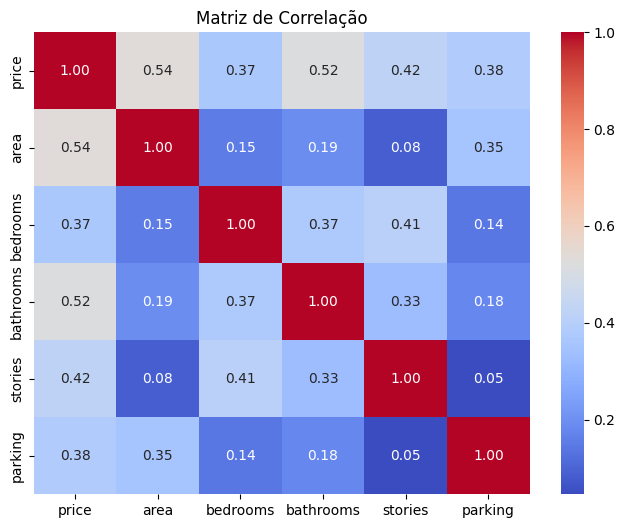

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação indica que todas as variáveis analisadas possuem uma correlação positiva com o preço, sendo a área (0.54) e o número de banheiros (0.52) os fatores com maior influência direta no valor do imóvel.
O número de andares (0.42), vagas de garagem (0.38) e quartos (0.37) apresentam correlações moderadas, sugerindo que também são preditores relevantes para o modelo.
Entre as variáveis independentes, observa-se uma relação moderada entre quartos e andares (0.41) e entre quartos e banheiros (0.37), mas a ausência de coeficientes extremamente elevados (acima de 0.80) sugere que não há problemas críticos de multicolinearidade, o que favorece a estabilidade de algoritmos de regressão para a projeção de preços.

### Gráficos de dispersão

Os gráficos de dispersão são utilizados com o objetivo de investigar a relação entre a variável alvo (price) e as demais variáveis explicativas. Essa abordagem permite visualizar padrões de associação, identificar possíveis relações lineares ou não lineares, além de evidenciar a presença de outliers e a dispersão dos dados.

Os gráficos de dispersão complementam a análise de correlação, possibilitando uma interpretação mais aprofundada das relações entre as variáveis, uma vez que a correlação linear, por si só, não captura totalmente a complexidade dos dados. Dessa forma, essa etapa contribui para validar os principais fatores associados ao preço dos imóveis e apoiar decisões mais fundamentadas na etapa de modelagem.

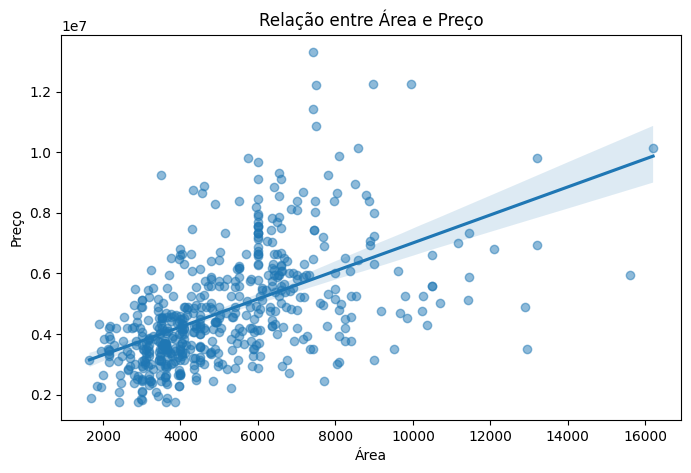

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x area
sns.regplot(x=df['area'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Área e Preço')
plt.xlabel('Área')
plt.ylabel('Preço')

plt.show()

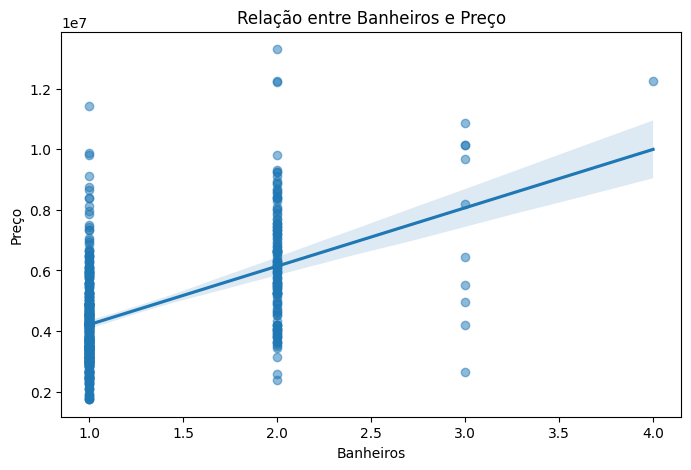

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x banheiros
sns.regplot(x=df['bathrooms'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Banheiros e Preço')
plt.xlabel('Banheiros')
plt.ylabel('Preço')

plt.show()

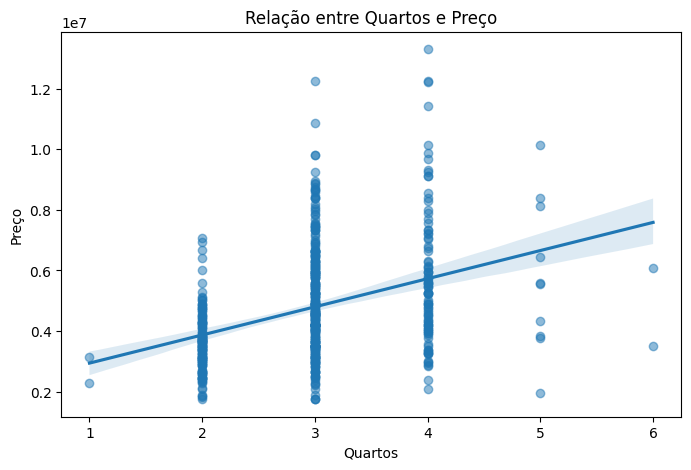

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x quartos
sns.regplot(x=df['bedrooms'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Quartos e Preço')
plt.xlabel('Quartos')
plt.ylabel('Preço')

plt.show()

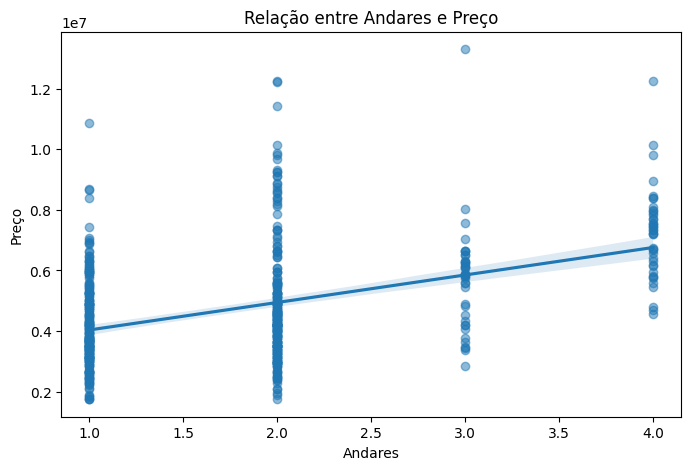

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x andares
sns.regplot(x=df['stories'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Andares e Preço')
plt.xlabel('Andares')
plt.ylabel('Preço')

plt.show()

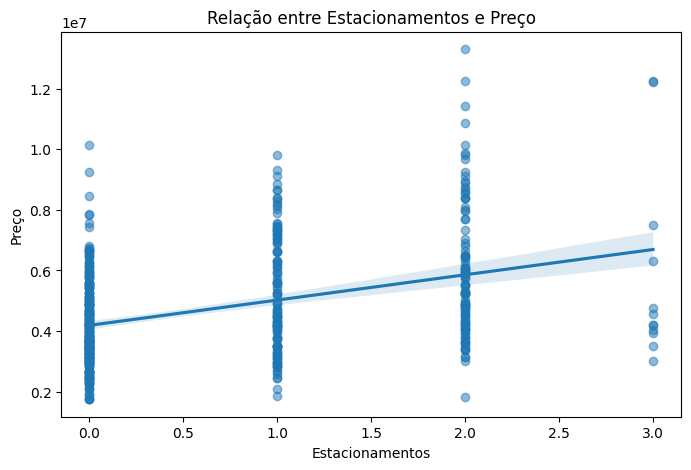

In [ ]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x estacionamentos
sns.regplot(x=df['parking'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Estacionamentos e Preço')
plt.xlabel('Estacionamentos')
plt.ylabel('Preço')

plt.show()

A análise integrada da matriz de correlação e dos gráficos de dispersão revela que, embora exista uma tendência linear positiva entre as características físicas e o preço, essa relação é complexa e marcada por uma elevada variabilidade interna.

De um lado, o heatmap confirma que a área (0.54) e o número de banheiros (0.52) são os principais vetores de valor, apresentando os coeficientes de correlação mais robustos da base de dados.

Visualmente, isso se traduz em linhas de regressão claramente ascendentes em todos os gráficos de dispersão, validando estatisticamente que o incremento em atributos como quartos, vagas e andares geralmente impulsiona o valor de mercado da propriedade.

Por outro lado, a observação detalhada dos gráficos de dispersão expõe a imperfeição dessa linearidade, especialmente nas variáveis discretas, que se manifestam como "colunas verticais" de dados.

Nestas variáveis, nota-se uma sobreposição massiva de preços entre diferentes categorias: é comum encontrar imóveis com apenas 2 quartos que superam em preço unidades com 3 ou 4 quartos, ou casas sem vagas de garagem custando mais do que aquelas com duas vagas.

Essa dispersão acentuada dentro de cada nível (como a amplitude observada em imóveis de 2 andares) demonstra que o preço é multifatorial.

O valor final não é determinado por um único atributo isolado, mas pela interação entre eles; uma área total maior ou uma localização privilegiada podem facilmente compensar a falta de um quarto adicional.

Essa dualidade explica por que as correlações com o preço, apesar de positivas, situam-se em patamares moderados (entre 0.37 e 0.54) e não próximos da perfeição.

A presença de outliers de alto valor no topo de todos os gráficos reforça que o segmento de luxo se descola da tendência média da massa de dados, apresentando comportamentos que desafiam a média linear.

Para o projeto de ciência de dados, esses resultados indicam que modelos preditivos simples podem sofrer com a alta variância dos dados, tornando essencial o uso de algoritmos capazes de captar essas nuances e interdependências para gerar projeções de preço mais precisas e menos enviesadas pela dispersão natural do mercado.

## Variáveis categóricas

A análise das variáveis categóricas tem como objetivo complementar a compreensão do comportamento do preço dos imóveis, incorporando atributos qualitativos que não são capturados pelas variáveis numéricas.

### Boxplot

 Busca comparar visualmente a distribuição dos preços entre as diferentes categorias, evidenciando diferenças de mediana, dispersão e presença de outliers.

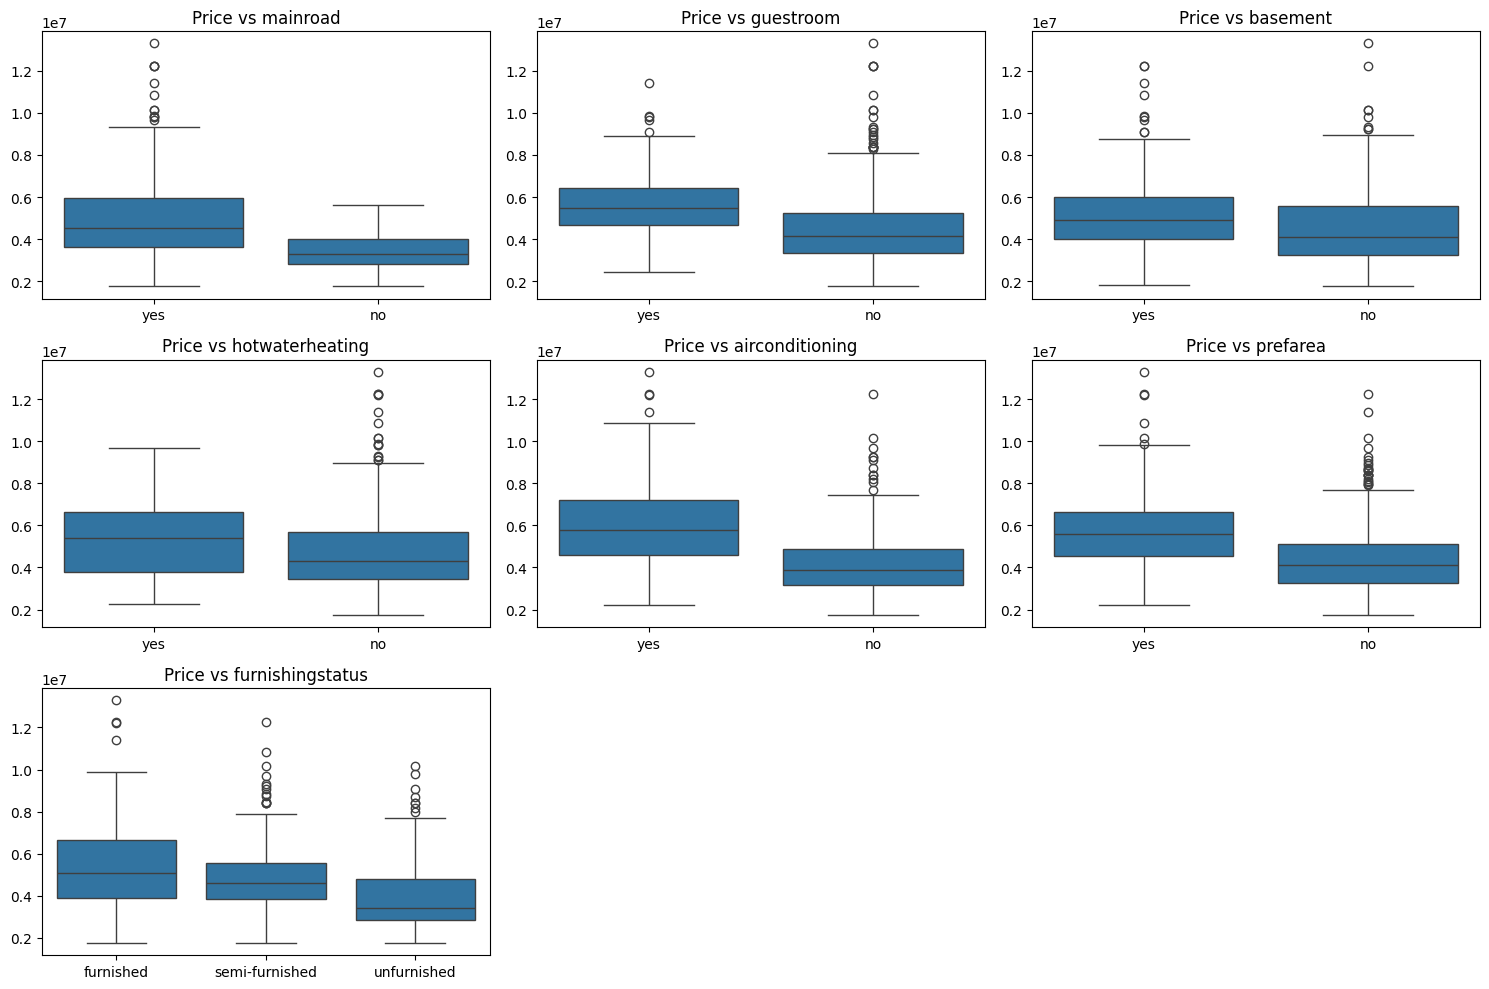

In [ ]:
# lista das variáveis categóricas
categorical_vars = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

n_cols = 3
n_rows = (len(categorical_vars) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 10))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(n_rows, n_cols, i)

    # aplica ordem apenas para variáveis binárias
    if df[var].nunique() == 2:
        sns.boxplot(x=var, y='price', data=df, order=['yes', 'no'])
    else:
        sns.boxplot(x=var, y='price', data=df)

    plt.title(f'Price vs {var}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Mediana de preço por grupo

Fornece uma medida objetiva dessas diferenças, reforçando os padrões observados graficamente.

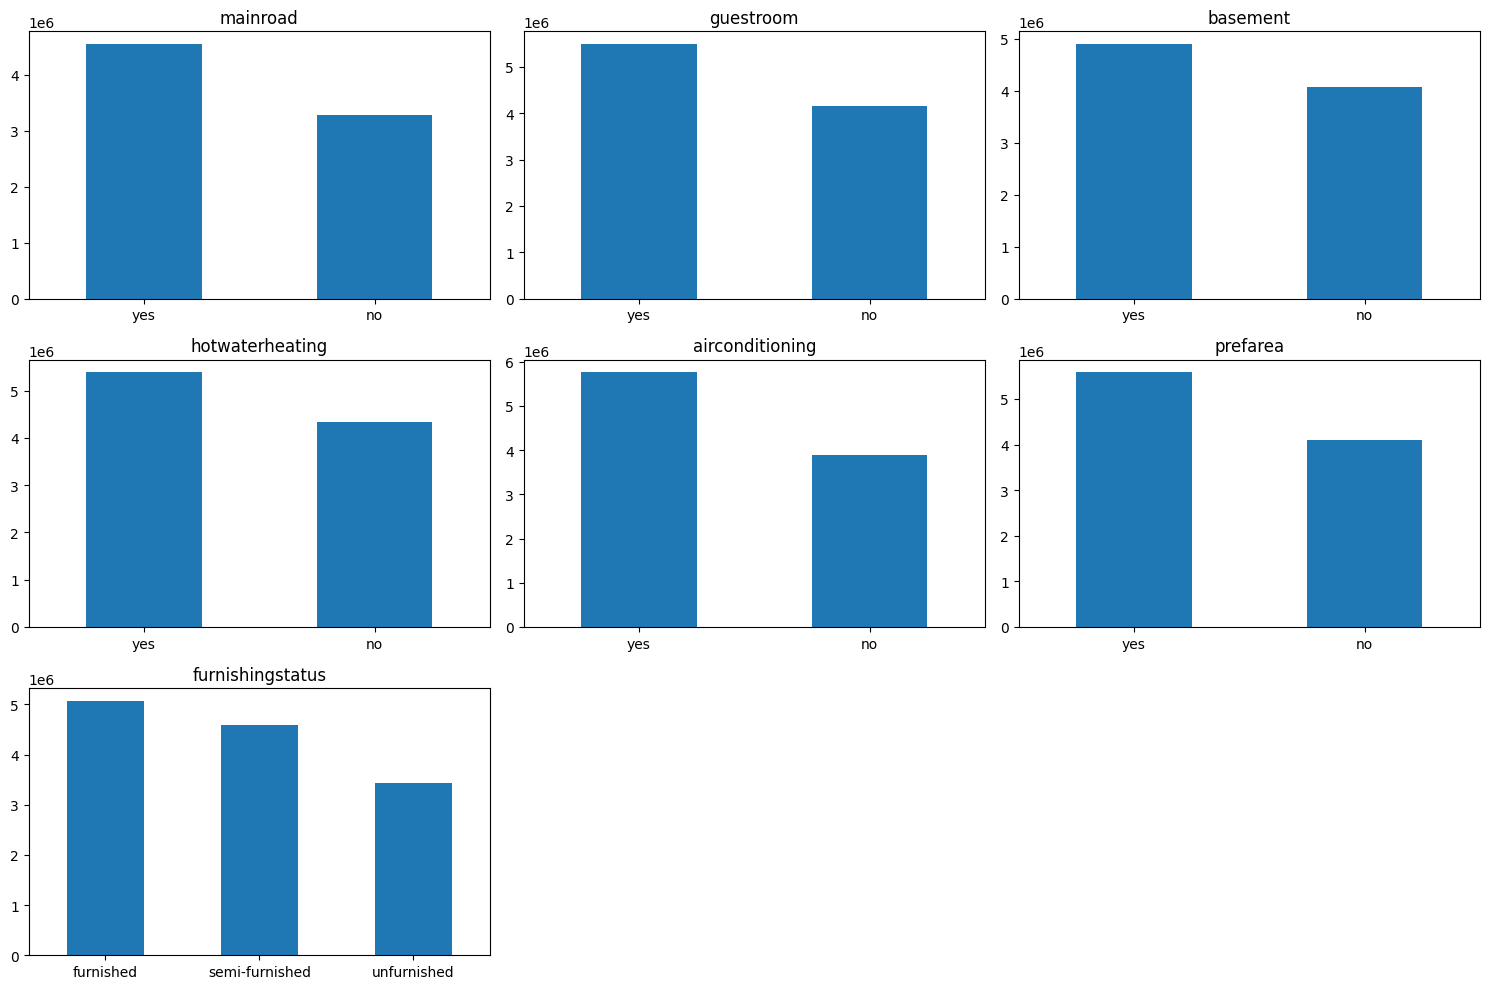

In [ ]:
# lista das variáveis categóricas
categorical_vars = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

# layout da grade
n_cols = 3
n_rows = (len(categorical_vars) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 10))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(n_rows, n_cols, i)

    medians = df.groupby(var)['price'].median().sort_values(ascending=False)
    medians.plot(kind='bar')

    plt.title(var)
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

A análise conjunta dos boxplots e dos gráficos de mediana por grupo permite uma avaliação mais robusta e consistente do impacto das variáveis categóricas sobre o preço dos imóveis, combinando evidência visual (distribuição) com medidas estatísticas (mediana).

Entre todas as variáveis, airconditioning e prefarea se destacam como os fatores de maior impacto. Nos boxplots, essas variáveis apresentam uma separação mais clara entre as categorias “yes” e “no”, com menor sobreposição relativa e maior deslocamento da mediana. Essa evidência é confirmada nos gráficos de barras, onde essas categorias apresentam as maiores medianas de preço entre todas as variáveis analisadas. Isso indica que tanto a presença de ar-condicionado quanto a localização em áreas valorizadas são determinantes relevantes na precificação dos imóveis.

As variáveis guestroom e basement também apresentam impacto positivo, com medianas mais elevadas nas categorias “yes”. No entanto, os boxplots mostram uma sobreposição considerável entre os grupos, indicando que, embora contribuam para a valorização, seu efeito é mais moderado e dependente de outros fatores. Os gráficos de mediana reforçam essa interpretação ao mostrar diferenças consistentes, porém menos acentuadas.

No caso de mainroad, observa-se um impacto intermediário. A mediana de imóveis com acesso à via principal é superior, mas a dispersão e a sobreposição indicam que esse atributo, isoladamente, não é suficiente para explicar grandes variações de preço.

A variável hotwaterheating apresenta um comportamento interessante: apesar de a mediana ser maior para imóveis com esse recurso, a diferença não é tão expressiva visualmente nos boxplots, sugerindo que seu impacto é relativamente limitado ou possivelmente influenciado por outros atributos correlacionados.

Já a variável furnishingstatus apresenta um padrão bem definido e consistente: imóveis mobiliados possuem maior mediana de preço, seguidos pelos semi-mobiliados e, por fim, os não mobiliados. Esse comportamento aparece de forma clara tanto nos boxplots quanto nos gráficos de barras, indicando uma relação ordinal bem estruturada. Ainda assim, a presença de sobreposição entre os grupos reforça que esse fator não atua de forma isolada.

Outro ponto importante é a presença de outliers em todas as variáveis, especialmente na faixa superior de preços. Esses valores extremos, já identificados anteriormente, continuam aparecendo independentemente da categoria analisada, indicando que imóveis de alto padrão estão distribuídos em diferentes perfis e não concentrados em uma única característica específica.

Por fim, a análise conjunta reforça a principal conclusão do projeto até aqui: o preço dos imóveis é resultado de um processo multifatorial. Embora variáveis categóricas como localização (prefarea) e infraestrutura (airconditioning) tenham impacto significativo, nenhuma variável isolada é capaz de explicar completamente a variabilidade dos preços. A combinação entre atributos qualitativos e quantitativos é essencial, o que justifica a necessidade de modelos preditivos mais robustos, capazes de capturar essas interações e não linearidades.

## 4.1 Síntese da análise exploratória

A análise exploratória permitiu compreender a estrutura dos dados e identificar características relevantes para as etapas posteriores de pré-processamento e modelagem.

Inicialmente, verificou-se que o conjunto de dados possui 545 observações e 13 variáveis, sem a presença de valores ausentes.

As variáveis numéricas apresentam escalas bastante diferentes. Enquanto o preço e a área possuem magnitudes elevadas, variáveis como número de quartos, banheiros, andares e vagas de estacionamento assumem valores relativamente pequenos. Essa diferença de escala deve ser considerada na escolha dos algoritmos e das técnicas de pré-processamento.

As variáveis categóricas devem ser submetidas às técnicas de codificação para utilização em algoritmos de Machine Learning.

Por fim, os resultados mostram que o preço dos imóveis é influenciado por um conjunto de fatores interdependentes, com destaque para área, localização e características estruturais. Nenhuma variável isoladamente explica o comportamento do preço, o que reforça a necessidade de modelos preditivos capazes de capturar relações não lineares e interações entre variáveis, como o Random Forest.


# 5. Preparação dos dados e divisão treino/teste


In [ ]:
# Cópia do dataset
df_model = df.copy()


## Transformação Logarítmica

A transformação logarítmica foi aplicada às variáveis price e area com o objetivo de reduzir a assimetria à direita identificada na análise exploratória. Essa técnica contribui para a estabilização da variância, diminui o impacto de outliers e melhora a adequação dos dados a modelos preditivos, especialmente aqueles que assumem relações mais próximas da linearidade.

In [ ]:
# Transformações logarítimicas
df_model['price'] = np.log(df_model['price'])
df_model['area'] = np.log(df_model['area'])


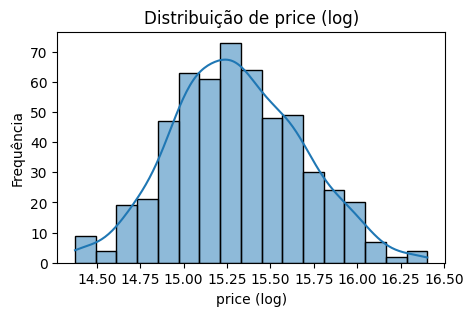

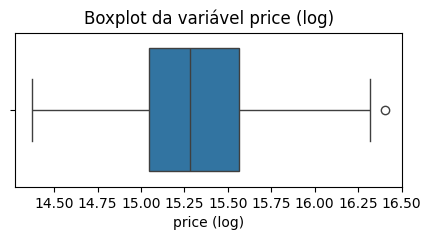

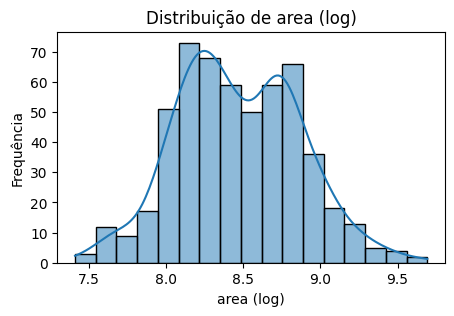

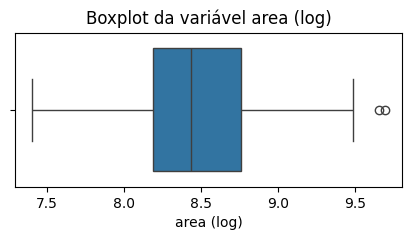

In [ ]:
variaveis = ['price', 'area']

for var in variaveis:

    # Histograma
    plt.figure(figsize=(5, 3))
    sns.histplot(df_model[var], kde=True)
    plt.title(f'Distribuição de {var} (log)')
    plt.xlabel(f'{var} (log)')
    plt.ylabel('Frequência')
    plt.show()

    # Boxplot
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_model[var])
    plt.title(f'Boxplot da variável {var} (log)')
    plt.xlabel(f'{var} (log)')
    plt.show()

Com essa transformação, as distribuições tornaram-se visivelmente mais simétricas e próximas da normalidade, apresentando um comportamento muito mais equilibrado nos histogramas
. Essa mudança é nitidamente confirmada pelos novos boxplots, onde a escala comprimida conseguiu "puxar" os valores extremos para mais perto da mediana, reduzindo drasticamente a incidência de pontos fora da curva e centralizando a massa de dados
. Para o sucesso do modelo de projeção de preços, esse tratamento é um passo crítico, pois mitiga o viés causado por propriedades excepcionalmente grandes ou caras e prepara as variáveis para que o algoritmo de regressão trabalhe com relações mais lineares e uma variância mais estável.

## Codificação de Variáveis Categóricas (Encoding)

As variáveis categóricas foram convertidas para formato numérico a fim de viabilizar sua utilização em modelos de machine learning. As variáveis binárias foram transformadas em valores 0 e 1, enquanto a variável furnishingstatus foi codificada de forma ordinal, respeitando a hierarquia entre suas categorias. Esse processo garante que as informações qualitativas sejam incorporadas de forma adequada ao modelo.

In [ ]:
# Encoding variáveis categóricas binárias
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

In [ ]:
# Encoding variável categórica ordinal
df_model['furnishingstatus'] = df_model['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

In [ ]:
# primeiras linhas
df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,16.403275,8.911934,4,2,3,1,0,0,0,1,2,1,2
1,16.321036,9.100526,4,4,4,1,0,0,0,1,3,0,2
2,16.321036,9.206332,3,2,2,1,0,1,0,0,2,1,1
3,16.318175,8.922658,4,2,2,1,0,1,0,1,3,1,2
4,16.250001,8.911934,4,1,2,1,1,1,0,1,2,0,2


## Separação entre Variáveis Independentes e Dependente (X e Y)

O conjunto de dados foi dividido entre variáveis explicativas (X) e variável alvo (Y), sendo esta representada pelo preço dos imóveis (price). Essa separação é fundamental para estruturar o problema de aprendizado supervisionado, permitindo que o modelo aprenda a relação entre os atributos dos imóveis e seu respectivo valor de mercado.

In [ ]:
# Separar X e Y
X = df_model.drop('price', axis=1)
y = df_model['price']

## Divisão em Treino e Teste (Train-Test Split)

Os dados foram divididos em conjuntos de treino e teste, com o objetivo de avaliar o desempenho do modelo em dados não vistos. O conjunto de treino é utilizado para o ajuste do modelo, enquanto o conjunto de teste permite medir sua capacidade de generalização, evitando problemas como overfitting e garantindo maior confiabilidade nas previsões.

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 5.1 Justificativa da divisão

Foi adotada a estratégia de holdout, na qual o conjunto de dados é dividido em subconjuntos independentes de treinamento e teste. Essa abordagem é amplamente utilizada em problemas de regressão supervisionada e permite avaliar a capacidade de generalização dos modelos em dados não observados durante o treinamento.

A divisão foi realizada na proporção de 80% para treinamento e 20% para teste, resultando em aproximadamente 436 observações para treinamento e 109 observações para teste. Considerando que o dataset possui 545 registros, essa proporção oferece um equilíbrio adequado entre a quantidade de dados disponível para o aprendizado dos modelos e a necessidade de reservar um conjunto independente para avaliação de desempenho.

Para garantir a reprodutibilidade dos resultados, foi utilizado o parâmetro random_state=42 durante a divisão dos dados. Além disso, o conjunto de teste foi mantido separado do processo de treinamento dos modelos, permitindo uma avaliação imparcial da capacidade preditiva das abordagens analisadas.

Embora tenham sido aplicadas transformações de codificação e transformação logarítmica antes da divisão, essas operações são determinísticas e não dependem de estatísticas calculadas a partir dos dados, não caracterizando vazamento de informação entre os conjuntos de treinamento e teste. Dessa forma, o conjunto de teste permaneceu adequado para a avaliação final dos modelos.

# 6. Pré-processamento e pipeline



In [ ]:
# Regressão Linear
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])


In [ ]:
# Random Forest
pipeline_rf = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [ ]:
# XGBoost
pipeline_xgb = Pipeline([
    ('model', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## 6.1 Decisões de pré-processamento

Em relação aos pipelines, a Regressão Linear foi combinada com a etapa de padronização por meio do StandardScaler. Essa escolha foi realizada porque modelos lineares podem ser influenciados por diferenças de escala entre as variáveis explicativas, e a padronização contribui para maior estabilidade numérica do processo de estimação.

Por outro lado, os modelos Random Forest e XGBoost não receberam etapas adicionais de normalização ou padronização. Como ambos são algoritmos baseados em árvores de decisão, seu desempenho não depende da escala das variáveis, tornando essa transformação desnecessária. Dessa forma, os pipelines desses modelos foram compostos apenas pelo algoritmo de aprendizado propriamente dito.

# 7. Baseline e modelos candidatos

Baseline: Regressão Linear

Modelo candidato 1: Random Forest

Modelo candidato 2: XGBoost


## 7.1 Justificativa dos modelos

A escolha dos modelos buscou comparar abordagens com diferentes níveis de complexidade para a previsão do preço de imóveis. O objetivo é verificar se modelos mais sofisticados conseguem capturar padrões adicionais nos dados em relação a uma abordagem linear tradicional.

A Regressão Linear foi adotada como modelo baseline por ser um dos métodos mais simples e interpretáveis para problemas de regressão. Esse modelo assume uma relação linear entre as variáveis explicativas e o preço do imóvel, servindo como uma referência inicial para avaliar os ganhos obtidos com algoritmos mais complexos. Além disso, seus coeficientes permitem compreender a direção e a intensidade da influência de cada variável sobre a variável alvo.

Como primeiro modelo candidato foi utilizado o Random Forest, um algoritmo baseado em conjuntos de árvores de decisão. Esse método é adequado para problemas de regressão com dados tabulares, pois consegue capturar relações não lineares e interações entre variáveis sem exigir hipóteses rígidas sobre a distribuição dos dados. O Random Forest também é relativamente robusto à presença de outliers e não requer normalização ou padronização das variáveis de entrada.

O segundo modelo candidato foi o XGBoost, uma técnica de Gradient Boosting amplamente utilizada em problemas de previsão com dados estruturados. O algoritmo constrói árvores de forma sequencial, buscando corrigir os erros cometidos pelas árvores anteriores. Essa característica permite modelar relações complexas entre os atributos dos imóveis e seus preços, frequentemente resultando em elevado desempenho preditivo.

Os três modelos são adequados ao tamanho do conjunto de dados, composto por 545 observações e um número reduzido de variáveis explicativas. Além disso, após o processo de codificação das variáveis categóricas, todos os atributos passaram a estar representados numericamente, permitindo sua utilização pelos algoritmos selecionados.

Em relação ao pré-processamento, apenas a Regressão Linear foi combinada com padronização das variáveis por meio do StandardScaler, uma vez que modelos lineares podem ser influenciados por diferenças de escala entre os atributos. Já o Random Forest e o XGBoost não exigem padronização, pois são baseados em árvores de decisão e não dependem da magnitude das variáveis para realizar as divisões.

Por fim, existe um compromisso entre interpretabilidade e desempenho. A Regressão Linear apresenta maior facilidade de interpretação, permitindo analisar diretamente o efeito das variáveis sobre o preço dos imóveis. Em contrapartida, Random Forest e XGBoost tendem a apresentar maior capacidade preditiva, porém com menor transparência na explicação das previsões individuais. Como o conjunto de dados possui dimensão moderada, o custo computacional de treinamento dos três modelos é baixo e não representa uma limitação para o desenvolvimento deste projeto.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
# Função de avaliação
def evaluate_regression(y_true, y_pred):

    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

# Modelos
models = {
    'Regressão Linear': pipeline_lr,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb
}

# Treinamento e avaliação
results = {}
trained_models = {}

for name, model in models.items():

    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    results[name] = evaluate_regression(
        y_test,
        y_pred
    )

    results[name]['train_time_s'] = round(
        train_time,
        3
    )

    trained_models[name] = model

# Tabela de resultados
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(by='R2', ascending=False)
)

results_df


,MAE,RMSE,R2,train_time_s
Regressão Linear,0.204225,0.254919,0.663452,0.008
XGBoost,0.204513,0.256206,0.660045,0.062
Random Forest,0.208388,0.265896,0.633844,0.495


## 8.1 Análise dos resultados iniciais

A Tabela de Resultados apresenta o desempenho dos três modelos avaliados: Regressão Linear (baseline), Random Forest e XGBoost. A comparação foi realizada utilizando as métricas MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), R² (Coeficiente de Determinação) e tempo de treinamento.

Observa-se que a Regressão Linear apresentou o melhor desempenho geral, obtendo os menores valores de MAE (0,2042) e RMSE (0,2549), além do maior coeficiente de determinação (R² = 0,6635). O modelo XGBoost apresentou desempenho bastante próximo ao baseline, com R² de 0,6600, enquanto o Random Forest apresentou o menor desempenho entre os modelos avaliados, com R² de 0,6338.

Dessa forma, os modelos candidatos não conseguiram superar o baseline, indicando que a relação entre as variáveis explicativas e o preço dos imóveis pode ser adequadamente representada por uma abordagem linear após as transformações realizadas durante o pré-processamento. Em particular, a transformação logarítmica aplicada às variáveis price e area provavelmente contribuiu para tornar as relações entre as variáveis mais lineares, favorecendo o desempenho da Regressão Linear.

As métricas utilizadas são adequadas para o problema proposto, uma vez que se trata de uma tarefa de regressão. O MAE fornece uma medida intuitiva do erro médio das previsões, enquanto o RMSE penaliza mais fortemente erros elevados. Já o R² permite avaliar a proporção da variabilidade dos preços explicada pelo modelo. A utilização conjunta dessas métricas proporciona uma avaliação mais completa do desempenho dos algoritmos do que a utilização de uma única métrica isoladamente.

Não há evidências claras de underfitting nos modelos avaliados. O melhor modelo foi capaz de explicar aproximadamente 66% da variabilidade observada nos preços dos imóveis, resultado considerado satisfatório para um conjunto de dados relativamente pequeno e com número limitado de atributos. Além disso, o desempenho semelhante entre Regressão Linear e XGBoost sugere que os dados podem não apresentar relações não lineares suficientemente complexas para justificar modelos mais sofisticados.

Em relação ao custo computacional, todos os tempos de treinamento foram baixos. A Regressão Linear foi treinada em apenas 0,008 segundos, enquanto o XGBoost e o Random Forest demandaram aproximadamente 0,06 e 0,5 segundos, respectivamente. Portanto, o tempo de processamento não representa uma limitação para a aplicação de nenhum dos modelos considerados.

Os resultados também são coerentes com os achados da Análise Exploratória de Dados (EDA). A ausência de valores faltantes, o número reduzido de variáveis explicativas e a forte influência esperada de atributos como área, número de banheiros, quartos e vagas de estacionamento sugeriam que uma parcela significativa da variação dos preços poderia ser capturada por relações relativamente simples. Isso ajuda a explicar o desempenho competitivo da Regressão Linear e a ausência de ganhos significativos por parte dos modelos baseados em árvores.


# 9. Validação e otimização de hiperparâmetros



In [ ]:
# Grade de hiperparâmetros
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

# Grid Search com validação cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Treinamento
grid_search.fit(X_train, y_train)

# Melhor modelo encontrado
best_xgb = grid_search.best_estimator_

# Previsões no conjunto de teste
y_pred_best = best_xgb.predict(X_test)

# Métricas finais
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

# Resultados
print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor RMSE médio na validação cruzada:")
print(-grid_search.best_score_)

print("\nDesempenho no conjunto de teste:")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Tabela resumo
pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Valor': [mae, rmse, r2]
})


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhores hiperparâmetros:
{'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100}

Melhor RMSE médio na validação cruzada:
0.20589511824763015

Desempenho no conjunto de teste:
MAE : 0.2058
RMSE: 0.2576
R²  : 0.6564


,Métrica,Valor
0,MAE,0.205757
1,RMSE,0.257569
2,R²,0.656417


## 9.1 Discussão da otimização

Com o objetivo de investigar possíveis ganhos de desempenho, foi realizada uma etapa de otimização de hiperparâmetros no modelo XGBoost, escolhido por apresentar desempenho competitivo na avaliação inicial e por possuir diversos parâmetros capazes de influenciar sua capacidade preditiva.

A busca foi conduzida por meio da técnica Grid Search associada à validação cruzada com 5 folds. Essa estratégia permite avaliar múltiplas combinações de hiperparâmetros utilizando diferentes subconjuntos dos dados de treinamento, reduzindo a dependência de uma única divisão dos dados e fornecendo uma estimativa mais robusta do desempenho esperado do modelo.

Foram avaliadas combinações dos hiperparâmetros n_estimators, max_depth e learning_rate, responsáveis por controlar respectivamente a quantidade de árvores, a complexidade das árvores e a velocidade de aprendizado do algoritmo. A seleção da melhor configuração foi guiada pela métrica RMSE (Root Mean Squared Error), amplamente utilizada em problemas de regressão por penalizar mais fortemente previsões com erros elevados.

Após a execução da busca, o modelo otimizado foi avaliado no conjunto de teste, obtendo MAE de 0,2058, RMSE de 0,2576 e R² de 0,6564. Ao comparar esses resultados com os obtidos pelo XGBoost antes da otimização, observa-se que não houve melhoria de desempenho. Pelo contrário, verificou-se uma pequena redução no valor de R² e um ligeiro aumento dos erros MAE e RMSE.

Esse resultado sugere que a configuração inicial do XGBoost já se encontrava próxima de uma solução adequada para o conjunto de dados analisado. Além disso, indica que a estrutura dos dados não apresenta padrões suficientemente complexos para que ajustes adicionais nos hiperparâmetros produzam ganhos relevantes de desempenho.

A busca realizada foi compatível com os objetivos de um MVP e não sofreu limitações significativas de tempo ou capacidade computacional, uma vez que o conjunto de dados possui apenas 545 observações. Entretanto, por questões de simplicidade e escopo do projeto, foram testadas apenas combinações de alguns dos principais hiperparâmetros do algoritmo.

Caso houvesse mais tempo para aprofundar a análise, poderiam ser avaliados outros parâmetros do XGBoost, como subsample, colsample_bytree, gamma e min_child_weight, além da utilização de técnicas mais avançadas de otimização, como Random Search ou Bayesian Optimization. Também seria interessante comparar os resultados obtidos com e sem as transformações logarítmicas aplicadas às variáveis price e area, permitindo investigar o impacto dessa decisão de pré-processamento sobre os diferentes modelos avaliados.

De forma geral, os resultados da otimização reforçam as conclusões obtidas na etapa de avaliação inicial. A ausência de ganhos significativos para os modelos mais complexos sugere que as relações entre as variáveis explicativas e o preço dos imóveis são relativamente simples após as transformações realizadas nos dados. Isso ajuda a explicar o excelente desempenho da Regressão Linear, que apresentou o maior coeficiente de determinação (R² = 0,6635), os menores erros de previsão e o menor tempo de treinamento entre todos os modelos avaliados. Dessa forma, a Regressão Linear permaneceu como a alternativa mais adequada para o problema estudado, conciliando desempenho preditivo, interpretabilidade e simplicidade computacional.


# 10. Avaliação final no conjunto de teste




Avaliação Final - Regressão Linear


,Métrica,Valor
0,MAE,0.204225
1,RMSE,0.254919
2,R²,0.663452



Estatísticas dos resíduos:


,price
count,109.000000
mean,0.002484
std,0.256084
min,-0.596334
25%,-0.156289
50%,0.001178
75%,0.172677
max,0.622627


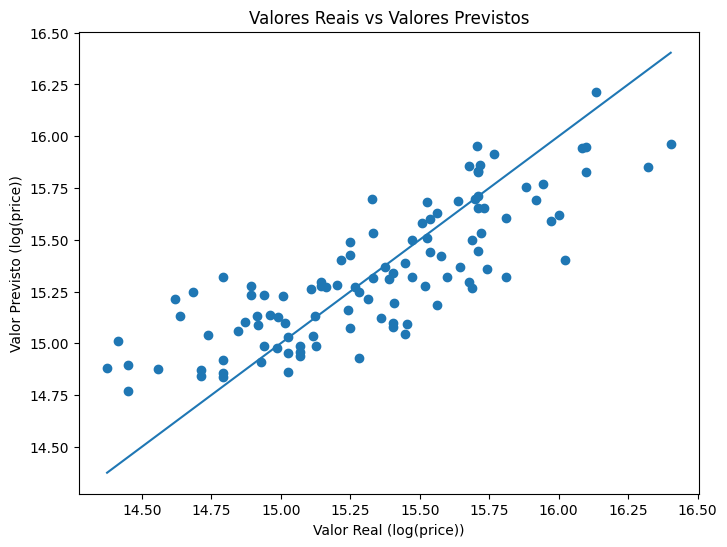

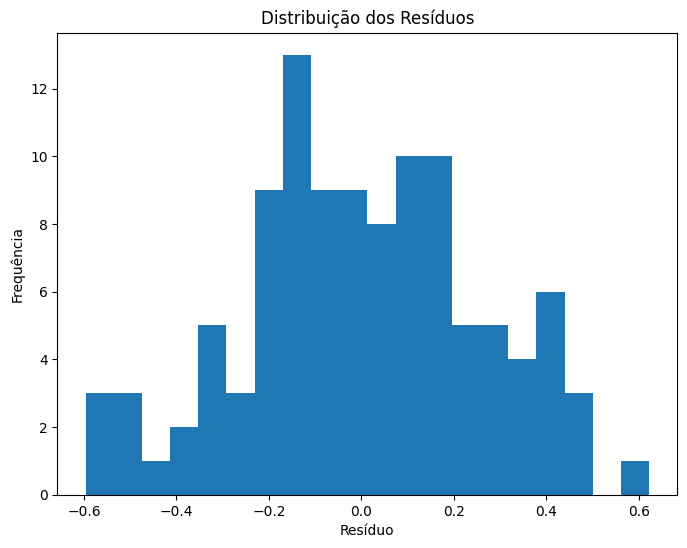

In [ ]:
# Previsões do modelo final
y_pred = pipeline_lr.predict(X_test)

# Métricas finais
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Resultados
resultado_final = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Valor': [mae, rmse, r2]
})

print("Avaliação Final - Regressão Linear")
display(resultado_final)

# Resíduos
residuos = y_test - y_pred

# Estatísticas dos resíduos
print("\nEstatísticas dos resíduos:")
display(residuos.describe())

# Gráfico Real x Previsto
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel('Valor Real (log(price))')
plt.ylabel('Valor Previsto (log(price))')
plt.title('Valores Reais vs Valores Previstos')
plt.show()

# Histograma dos resíduos
plt.figure(figsize=(8,6))
plt.hist(residuos, bins=20)
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.title('Distribuição dos Resíduos')
plt.show()


## 10.1 Análise de erros e limitações

A análise dos resultados obtidos indica que o modelo de Regressão Linear foi capaz de capturar adequadamente os principais padrões presentes nos dados, alcançando um coeficiente de determinação (R²) de 0,6635. O gráfico de valores reais versus valores previstos mostra uma concentração razoável dos pontos em torno da linha de referência, indicando que as previsões acompanham a tendência geral observada nos dados.

Entretanto, observa-se que os erros aumentam para alguns imóveis localizados nos extremos da distribuição de preços. Em especial, o modelo tende a apresentar maior dificuldade para estimar corretamente imóveis muito baratos ou muito caros. Esse comportamento é comum em modelos lineares, que podem ter dificuldade para representar relações mais complexas ou efeitos específicos presentes em determinadas faixas de preço.

A análise dos resíduos reforça essa conclusão. O histograma apresenta distribuição aproximadamente centrada em zero, com média dos resíduos de 0,0025, indicando que o modelo não apresenta viés sistemático de superestimação ou subestimação dos preços. Além disso, a mediana dos resíduos é praticamente nula (0,0012), sugerindo que os erros positivos e negativos estão razoavelmente equilibrados.

O desvio-padrão dos resíduos foi de aproximadamente 0,256, indicando uma dispersão moderada dos erros em torno do valor previsto. Os resíduos variaram entre -0,596 e 0,623, evidenciando a existência de alguns casos em que o modelo apresentou erros relativamente elevados. Esses casos podem estar associados a características dos imóveis não representadas pelas variáveis disponíveis na base de dados.

Não foram identificados sinais claros de overfitting, uma vez que modelos mais complexos, como Random Forest e XGBoost, não conseguiram superar o desempenho da Regressão Linear no conjunto de teste. Da mesma forma, não há evidências fortes de underfitting, pois o modelo conseguiu explicar aproximadamente dois terços da variabilidade observada nos preços dos imóveis. Ainda assim, o fato de cerca de 33% da variabilidade permanecer sem explicação indica que existem fatores relevantes não capturados pelos atributos disponíveis.

As métricas utilizadas (MAE, RMSE e R²) mostraram-se adequadas para o objetivo do projeto. O MAE permite interpretar o erro médio das previsões, o RMSE destaca erros de maior magnitude e o R² fornece uma medida global da capacidade explicativa do modelo. A utilização conjunta dessas métricas permitiu uma avaliação mais abrangente do desempenho obtido.

Entre as principais limitações da solução destacam-se o tamanho relativamente reduzido da base de dados (545 observações) e a ausência de variáveis frequentemente utilizadas em modelos imobiliários, como localização geográfica detalhada, idade do imóvel, padrão construtivo, qualidade do acabamento, proximidade de serviços e características socioeconômicas da região. A ausência dessas informações limita a capacidade do modelo de capturar toda a complexidade envolvida na formação dos preços.

Por fim, deve-se destacar que o modelo foi desenvolvido e validado utilizando dados provenientes de um único conjunto de dados. Dessa forma, não há garantia de que o desempenho observado será mantido em mercados imobiliários diferentes ou em regiões com características distintas. O modelo não deve ser utilizado como ferramenta única para avaliação financeira ou tomada de decisão em transações imobiliárias reais, sendo mais adequado como instrumento de apoio para estimativas preliminares de preços em contextos semelhantes aos representados pela base analisada.

# 11. Comparação final dos modelos

| Modelo | Métrica principal (RMSE) | Outras métricas | Tempo de treino (s) | Observações |
|----------|----------:|----------|----------:|----------|
| Baseline (Regressão Linear) | **0,2549** | MAE = 0,2042 <br> R² = 0,6635 | 0,008 | Melhor desempenho geral. Modelo simples, rápido e facilmente interpretável. |
| Random Forest | 0,2659 | MAE = 0,2084 <br> R² = 0,6338 | 0,762 | Não superou o baseline. Maior custo computacional e menor interpretabilidade. |
| XGBoost | 0,2562 | MAE = 0,2045 <br> R² = 0,6600 | 0,496 | Desempenho muito próximo ao baseline, porém com maior complexidade computacional. |
| XGBoost Otimizado | 0,2576 | MAE = 0,2058 <br> R² = 0,6564 | - | A otimização não trouxe ganhos de desempenho. Resultado ligeiramente inferior ao XGBoost inicial. |


# 12. Conclusão

O objetivo deste trabalho foi desenvolver e avaliar modelos de Machine Learning capazes de prever o preço de imóveis a partir de características estruturais dos imóveis, como área, número de quartos, número de banheiros, vagas de estacionamento, presença de ar-condicionado, proximidade de rodovia principal e nível de mobiliário.

Inicialmente, foi realizada uma análise exploratória dos dados, que permitiu compreender a distribuição das variáveis, identificar a ausência de valores faltantes e verificar a existência de assimetria em algumas variáveis, especialmente em relação ao preço e à área dos imóveis. Com base nesses achados, foram aplicadas transformações logarítmicas e procedimentos de codificação das variáveis categóricas, visando preparar os dados para a modelagem.

Foram avaliados três modelos de regressão: Regressão Linear, Random Forest e XGBoost. Os resultados mostraram que a Regressão Linear apresentou o melhor desempenho geral, alcançando R² de 0,6635, MAE de 0,2042 e RMSE de 0,2549. O XGBoost apresentou desempenho muito próximo ao modelo linear, enquanto o Random Forest obteve resultados inferiores. Posteriormente, foi realizada uma etapa de otimização de hiperparâmetros no XGBoost por meio de Grid Search com validação cruzada, porém sem ganhos significativos de desempenho.

A comparação entre os modelos demonstrou que abordagens mais complexas não necessariamente produzem melhores resultados. Após as transformações realizadas nos dados, a relação entre as variáveis explicativas e o preço dos imóveis tornou-se suficientemente bem representada por um modelo linear, permitindo que a Regressão Linear superasse modelos mais sofisticados tanto em desempenho quanto em eficiência computacional.

Entre os principais aprendizados obtidos neste projeto destaca-se a importância da análise exploratória e do pré-processamento dos dados. As transformações realizadas tiveram impacto direto na qualidade dos resultados, evidenciando que a preparação adequada dos dados pode ser tão importante quanto a escolha do algoritmo de Machine Learning.

Como limitações do estudo, destaca-se o tamanho relativamente reduzido da base de dados, composta por 545 observações, além da ausência de variáveis potencialmente relevantes para a determinação do preço dos imóveis, como localização geográfica detalhada, idade da construção, padrão de acabamento e características socioeconômicas da região. Essas limitações restringem a capacidade explicativa do modelo e sua generalização para outros contextos imobiliários.

Como trabalhos futuros, recomenda-se ampliar a base de dados, incorporar novas variáveis explicativas, realizar comparações entre modelos com e sem transformações logarítmicas e explorar técnicas mais avançadas de engenharia de atributos e otimização de hiperparâmetros. Também seria interessante avaliar o desempenho dos modelos em bases de dados de outras regiões geográficas para verificar sua capacidade de generalização.

De forma geral, os resultados obtidos demonstram que a Regressão Linear constitui uma solução adequada para o problema estudado, apresentando um equilíbrio favorável entre desempenho preditivo, interpretabilidade e simplicidade computacional, atendendo satisfatoriamente aos objetivos propostos neste MVP.

